In [41]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Dữ liệu giả lập với cả cột văn bản và cột số
data = {
    'Description': ['The movie was great', 'I love this product', 'Not bad at all', 'Terrible experience'],
    'Price': [100, 150, 120, 200],
    'Rating': [5, 4, 3, 1]
}

df = pd.DataFrame(data)

# Cột văn bản và cột số
text_columns = ['Description']
numeric_columns = ['Price', 'Rating']

# Áp dụng TfidfVectorizer cho cột văn bản và StandardScaler cho các cột số
preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(), 'Description'),  # Áp dụng TfidfVectorizer cho cột văn bản
        ('num', StandardScaler(), numeric_columns)  # Áp dụng StandardScaler cho các cột số
    ])

# Áp dụng ColumnTransformer trong một pipeline
pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

# Chuyển đổi dữ liệu
transformed_data = pipeline.fit_transform(df)

# Kết quả
pd.DataFrame(transformed_data)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,0.0,0.0,0.0,0.000000,0.5,0.00000,0.5,0.0,0.00000,0.000000,0.5,0.00000,0.5,-1.128330,1.183216
1,0.0,0.0,0.0,0.000000,0.0,0.57735,0.0,0.0,0.57735,0.000000,0.0,0.57735,0.0,0.199117,0.507093
2,0.5,0.5,0.5,0.000000,0.0,0.00000,0.0,0.5,0.00000,0.000000,0.0,0.00000,0.0,-0.597351,-0.169031
3,0.0,0.0,0.0,0.707107,0.0,0.00000,0.0,0.0,0.00000,0.707107,0.0,0.00000,0.0,1.526564,-1.521278


In [35]:
df

,Description,Price,Rating
0,The movie was great,100,5
1,I love this product,150,4
2,Not bad at all,120,3
3,Terrible experience,200,1


In [37]:
df['Description']

0    The movie was great
1    I love this product
2         Not bad at all
3    Terrible experience
Name: Description, dtype: object

In [39]:
tf_idf = TfidfVectorizer()
pd.DataFrame(tf_idf.fit_transform(data['Description']).toarray()

array([[0.        , 0.        , 0.        , 0.        , 0.5       ,
        0.        , 0.5       , 0.        , 0.        , 0.        ,
        0.5       , 0.        , 0.5       ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.57735027, 0.        , 0.        , 0.57735027, 0.        ,
        0.        , 0.57735027, 0.        ],
       [0.5       , 0.5       , 0.5       , 0.        , 0.        ,
        0.        , 0.        , 0.5       , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.70710678, 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.70710678,
        0.        , 0.        , 0.        ]])

In [3]:
from sklearn.model_selection import train_test_split

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [25]:
import scipy
from scipy.optimize import linear_sum_assignment
import numpy as np

In [31]:
arr = np.array([[1,2,3],[2,3,4],[3,4,5],[2,3,4]])

In [33]:
linear_sum_assignment(arr)

(array([0, 1, 3], dtype=int64), array([0, 1, 2], dtype=int64))

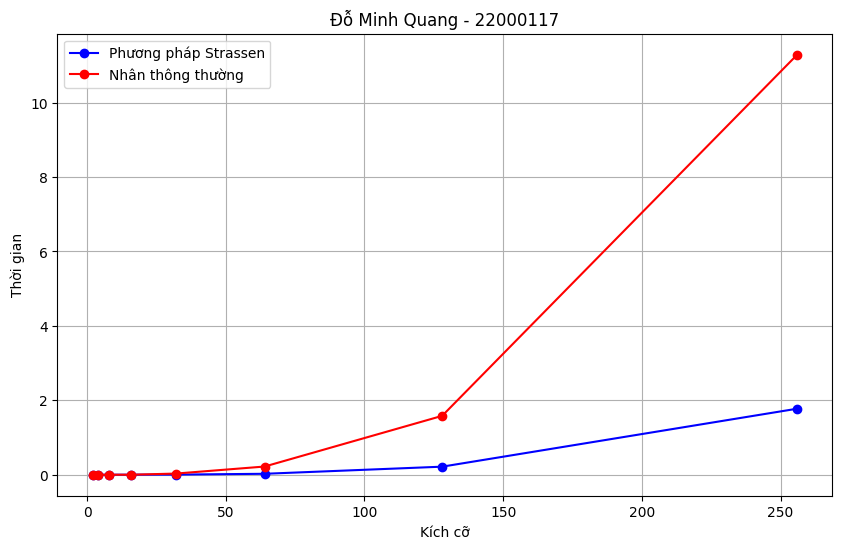

In [45]:
import numpy as np
import time
import matplotlib.pyplot as plt

# Hàm nhân ma trận thông thường
def matrix_multiply_standard(A, B):
    n = len(A)
    C = [[0] * n for _ in range(n)]
    for i in range(n):
        for j in range(n):
            for k in range(n):
                C[i][j] += A[i][k] * B[k][j]
    return C

# Hàm nhân ma trận Strassen (đơn giản hóa)
def matrix_multiply_strassen(A, B):
    n = len(A)
    
    # Trường hợp cơ sở
    if n <= 1:
        return [[A[0][0] * B[0][0]]]
    
    # Đảm bảo kích thước là lũy thừa của 2 bằng cách thêm padding nếu cần
    if n % 2 != 0:
        new_n = n + 1
        A_new = np.pad(A, ((0, 1), (0, 1)), mode='constant')
        B_new = np.pad(B, ((0, 1), (0, 1)), mode='constant')
        C = matrix_multiply_strassen(A_new, B_new)
        return [row[:n] for row in C[:n]]
    
    # Chia ma trận thành 4 phần
    mid = n // 2
    A11 = [row[:mid] for row in A[:mid]]
    A12 = [row[mid:] for row in A[:mid]]
    A21 = [row[:mid] for row in A[mid:]]
    A22 = [row[mid:] for row in A[mid:]]
    
    B11 = [row[:mid] for row in B[:mid]]
    B12 = [row[mid:] for row in B[:mid]]
    B21 = [row[:mid] for row in B[mid:]]
    B22 = [row[mid:] for row in B[mid:]]
    
    # 7 phép nhân đệ quy của Strassen
    P1 = matrix_multiply_strassen(A11, [[B12[i][j] - B22[i][j] for j in range(mid)] for i in range(mid)])
    P2 = matrix_multiply_strassen([[A11[i][j] + A12[i][j] for j in range(mid)] for i in range(mid)], B22)
    P3 = matrix_multiply_strassen([[A21[i][j] + A22[i][j] for j in range(mid)] for i in range(mid)], B11)
    P4 = matrix_multiply_strassen(A22, [[B21[i][j] - B11[i][j] for j in range(mid)] for i in range(mid)])
    P5 = matrix_multiply_strassen([[A11[i][j] + A22[i][j] for j in range(mid)] for i in range(mid)], 
                                 [[B11[i][j] + B22[i][j] for j in range(mid)] for i in range(mid)])
    P6 = matrix_multiply_strassen([[A12[i][j] - A22[i][j] for j in range(mid)] for i in range(mid)], 
                                 [[B21[i][j] + B22[i][j] for j in range(mid)] for i in range(mid)])
    P7 = matrix_multiply_strassen([[A11[i][j] - A21[i][j] for j in range(mid)] for i in range(mid)], 
                                 [[B11[i][j] + B12[i][j] for j in range(mid)] for i in range(mid)])
    
    # Tính các phần tư của ma trận kết quả
    C11 = [[P5[i][j] + P4[i][j] - P2[i][j] + P6[i][j] for j in range(mid)] for i in range(mid)]
    C12 = [[P1[i][j] + P2[i][j] for j in range(mid)] for i in range(mid)]
    C21 = [[P3[i][j] + P4[i][j] for j in range(mid)] for i in range(mid)]
    C22 = [[P5[i][j] + P1[i][j] - P3[i][j] - P7[i][j] for j in range(mid)] for i in range(mid)]
    
    # Ghép các phần tư thành ma trận hoàn chỉnh
    C = [[0] * n for _ in range(n)]
    for i in range(mid):
        for j in range(mid):
            C[i][j] = C11[i][j]
            C[i][j + mid] = C12[i][j]
            C[i + mid][j] = C21[i][j]
            C[i + mid][j + mid] = C22[i][j]
    
    return C

# Hàm đo thời gian thực thi
def measure_time(algorithm, sizes):
    times = []
    for n in sizes:
        # Tạo ma trận ngẫu nhiên
        A = np.random.rand(n, n).tolist()
        B = np.random.rand(n, n).tolist()
        
        start_time = time.time()
        algorithm(A, B)
        end_time = time.time()
        
        times.append(end_time - start_time)
    return times

# Các kích thước ma trận để thử nghiệm
sizes = [2, 4, 8, 16, 32, 64, 128, 256]  # Giới hạn kích thước để chạy nhanh hơn

# Đo thời gian cho cả hai thuật toán
standard_times = measure_time(matrix_multiply_standard, sizes)
strassen_times = measure_time(matrix_multiply_strassen, sizes)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
plt.plot(sizes, standard_times, 'b-o', label='Phương pháp Strassen')
plt.plot(sizes, strassen_times, 'r-o', label='Nhân thông thường')
plt.xlabel('Kích cỡ')
plt.ylabel('Thời gian')
plt.title('Đỗ Minh Quang - 22000117')
plt.legend()
plt.grid(True)
plt.show()

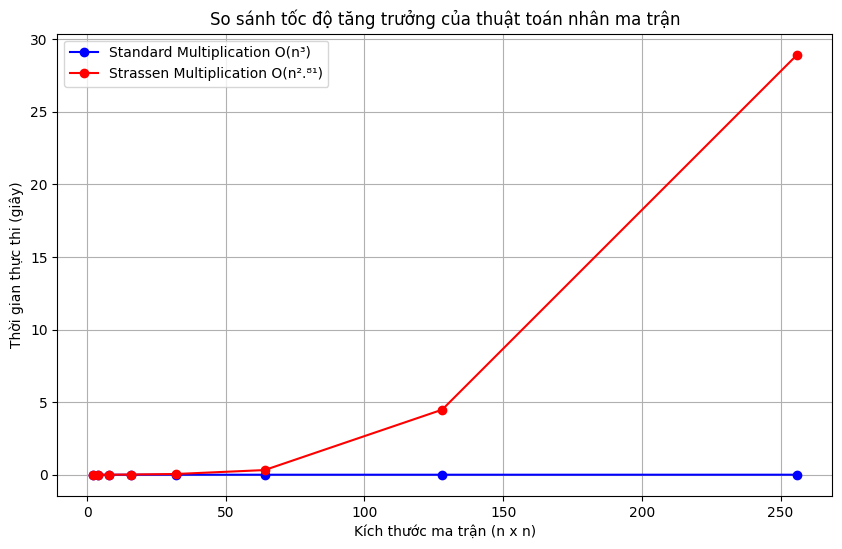

In [47]:
import numpy as np
import time
import matplotlib.pyplot as plt

# Hàm nhân ma trận thông thường
def matrix_multiply_standard(A, B):
    return np.dot(A, B)  # Sử dụng hàm dot của NumPy cho hiệu suất cao

# Hàm nhân ma trận Strassen
def matrix_multiply_strassen(A, B):
    n = A.shape[0]
    
    # Trường hợp cơ sở
    if n <= 1:
        return A * B
    
    # Đảm bảo kích thước là lũy thừa của 2 bằng cách thêm padding nếu cần
    if n % 2 != 0:
        new_n = n + 1
        A = np.pad(A, ((0, 1), (0, 1)), mode='constant')
        B = np.pad(B, ((0, 1), (0, 1)), mode='constant')
        C = matrix_multiply_strassen(A, B)
        return C[:n, :n]
    
    # Chia ma trận thành 4 phần
    mid = n // 2
    A11 = A[:mid, :mid]
    A12 = A[:mid, mid:]
    A21 = A[mid:, :mid]
    A22 = A[mid:, mid:]
    
    B11 = B[:mid, :mid]
    B12 = B[:mid, mid:]
    B21 = B[mid:, :mid]
    B22 = B[mid:, mid:]
    
    # 7 phép nhân đệ quy của Strassen
    P1 = matrix_multiply_strassen(A11, B12 - B22)
    P2 = matrix_multiply_strassen(A11 + A12, B22)
    P3 = matrix_multiply_strassen(A21 + A22, B11)
    P4 = matrix_multiply_strassen(A22, B21 - B11)
    P5 = matrix_multiply_strassen(A11 + A22, B11 + B22)
    P6 = matrix_multiply_strassen(A12 - A22, B21 + B22)
    P7 = matrix_multiply_strassen(A11 - A21, B11 + B12)
    
    # Tính các phần tư của ma trận kết quả
    C11 = P5 + P4 - P2 + P6
    C12 = P1 + P2
    C21 = P3 + P4
    C22 = P5 + P1 - P3 - P7
    
    # Ghép các phần tư thành ma trận hoàn chỉnh
    C = np.vstack((np.hstack((C11, C12)), np.hstack((C21, C22))))
    
    return C

# Hàm đo thời gian thực thi
def measure_time(algorithm, sizes):
    times = []
    for n in sizes:
        # Tạo ma trận ngẫu nhiên
        A = np.random.rand(n, n)
        B = np.random.rand(n, n)
        
        start_time = time.time()
        algorithm(A, B)
        end_time = time.time()
        
        times.append(end_time - start_time)
    return times

# Các kích thước ma trận để thử nghiệm
sizes = [2, 4, 8, 16, 32, 64, 128, 256]  # Có thể tăng kích thước để thấy rõ sự khác biệt

# Đo thời gian cho cả hai thuật toán
standard_times = measure_time(matrix_multiply_standard, sizes)
strassen_times = measure_time(matrix_multiply_strassen, sizes)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
plt.plot(sizes, standard_times, 'b-o', label='Standard Multiplication O(n³)')
plt.plot(sizes, strassen_times, 'r-o', label='Strassen Multiplication O(n².⁸¹)')
plt.xlabel('Kích thước ma trận (n x n)')
plt.ylabel('Thời gian thực thi (giây)')
plt.title('So sánh tốc độ tăng trưởng của thuật toán nhân ma trận')
plt.legend()
plt.grid(True)
plt.show()